## Peter's Multi-omics Analysis

In [1]:
import pandas as pd
import numpy as np

### Read-in and match metabolite centroids to visium centroids

In [2]:
SPACERANGER_DIR = "/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs"
metab_df = pd.read_csv(f"{SPACERANGER_DIR}/cell_segmentations_out1_cells_metabolites.csv")
metab_df

,cell_index,cell_id,centroid_x,centroid_y,n_pixels,m/z 61.98750,m/z 62.00260,m/z 62.96320,m/z 64.01830,Pyruvaldehyde [M-H]- [71.0132],...,"Adenosine 3',5'-diphosphate [M-H]- [426.0231]",Captopril disulfide [M-H]- [431.1312],Lexibulin [M-H]- [433.2365],LysoPA(0:0/18:1(9Z)) [M-H]- [435.2522],LysoPA(0:0/18:0) [M-H]- [437.2681],Menatetrenone Epoxide [M-H]- [459.2943],m/z 496.27500,Beloranib [M-H]- [498.2907],Sulfolithocholylglycine [M-H]- [512.2701],Taurocholic acid [M-H]- [514.2856]
0,0,0,5031.7,4015.6,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,1,1,5513.6,3490.1,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,2,2,7718.8,4190.9,24,0.0,0.428896,6.443443,1.159378,0.135478,...,15.290737,0.233051,1.166896,2.658346,3.572461,0.0,0.0,0.113973,0.0,3.191367
3,3,3,5794.3,3391.8,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
4,4,4,4851.3,3326.0,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62093,62093,62093,10979.4,9957.8,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62094,62094,62094,11137.7,10720.5,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62095,62095,62095,11269.0,8812.9,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62096,62096,62096,11146.7,10754.4,0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000


In [3]:
import json
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial import KDTree

SPACERANGER_DIR = "/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs"

# --- 1. Load cell x gene matrix ---
adata = sc.read_10x_h5(f"{SPACERANGER_DIR}/filtered_feature_cell_matrix.h5")
adata.obs["geojson_cell_id"] = (
    pd.Series(adata.obs_names)
    .str.extract(r"cellid_0*(\d+)")[0]
    .astype(int)
    .values
)

# --- 2. Build geojson centroid lookup (keyed by cell_id) ---
with open(f"{SPACERANGER_DIR}/cell_segmentations.geojson") as f:
    geojson = json.load(f)

geojson_records = []
for feat in geojson["features"]:
    cell_id = feat["properties"]["cell_id"]
    coords = np.array(feat["geometry"]["coordinates"][0])
    cx, cy = coords[:, 0].mean(), coords[:, 1].mean()
    geojson_records.append({"geojson_cell_id": cell_id, "centroid_x": cx, "centroid_y": cy})

geojson_df = pd.DataFrame(geojson_records)

# --- 3. Add geojson centroids to adata.obs ---
adata.obs = adata.obs.merge(geojson_df, on="geojson_cell_id", how="left")
adata.obs.index = adata.obs_names  # restore index after merge

# --- 4. Load metabolite matrix ---
metab_df = pd.read_csv(f"{SPACERANGER_DIR}/cell_segmentations_out1_cells_metabolites.csv")

# --- 5. KDTree match: for each adata cell centroid find nearest metabolite cell ---
tree = KDTree(metab_df[["centroid_x", "centroid_y"]].values)
adata_coords = adata.obs[["centroid_x", "centroid_y"]].values

dists, idx = tree.query(adata_coords, distance_upper_bound=10.0)

matched_metab_idx = np.where(dists < 10.0, idx, -1)

# --- 6. Pull matched metabolite rows into adata.obs ---
metab_cols = metab_df.columns.drop(["cell_index", "cell_id", "centroid_x", "centroid_y", "n_pixels"])
matched_metab = metab_df.iloc[
    np.where(matched_metab_idx >= 0, matched_metab_idx, 0)
][metab_cols].values

metab_matched_df = pd.DataFrame(matched_metab, index=adata.obs.index, columns=metab_cols)
metab_matched_df[matched_metab_idx < 0] = np.nan  # unmatched cells get NaN

adata.obs = pd.concat([adata.obs, metab_matched_df], axis=1)

print(f"Cells with metabolite match: {(matched_metab_idx >= 0).sum()} of {len(adata)}")


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kia/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Cells with metabolite match: 62098 of 62098


In [4]:
adata.obs

,geojson_cell_id,centroid_x,centroid_y,m/z 61.98750,m/z 62.00260,m/z 62.96320,m/z 64.01830,Pyruvaldehyde [M-H]- [71.0132],m/z 74.00290,Acetohydroxamic Acid [M-H]- [74.0240],...,"Adenosine 3',5'-diphosphate [M-H]- [426.0231]",Captopril disulfide [M-H]- [431.1312],Lexibulin [M-H]- [433.2365],LysoPA(0:0/18:1(9Z)) [M-H]- [435.2522],LysoPA(0:0/18:0) [M-H]- [437.2681],Menatetrenone Epoxide [M-H]- [459.2943],m/z 496.27500,Beloranib [M-H]- [498.2907],Sulfolithocholylglycine [M-H]- [512.2701],Taurocholic acid [M-H]- [514.2856]
0,1,5028.915152,4013.024242,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,2,5513.714286,3490.100000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,3,7718.620690,4187.948276,0.0,0.428896,6.443443,1.159378,0.135478,3.294319,0.298016,...,15.290737,0.233051,1.166896,2.658346,3.572461,0.0,0.0,0.113973,0.0,3.191367
3,4,5798.020000,3391.456000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
4,6,4849.100000,3324.425581,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62093,69963,10977.861290,9957.825806,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62094,69964,11138.454545,10719.445455,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62095,69965,11266.687097,8813.316129,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62096,69966,11144.360000,10752.346667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000


#### What I think Peter wants 
he wants the cells that have been annotated/ segmented to have the same borders across modalities. So segment the H&E then derive the cell borders. Have the cell borders filled with metabolite intesnity and visium gene expression. 

In [5]:
import scanpy as sc
import scipy.sparse as sp

# compute HVGs (adjust n_top_genes as needed)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# subset to HVGs only
adata_hvg = adata[:, adata.var["highly_variable"]]

expr_df = pd.DataFrame(
    adata_hvg.X.toarray() if sp.issparse(adata_hvg.X) else adata_hvg.X,
    index=adata_hvg.obs.index,
    columns=adata_hvg.var_names
)

result_df = adata_hvg.obs[["geojson_cell_id", "centroid_x", "centroid_y"]].join(expr_df)
#result_df.to_csv("cell_x_hvg_with_centroids_subsetted.csv")

result_df

,geojson_cell_id,centroid_x,centroid_y,Alkal1,Arfgef1,Slco5a1,Tram1,Msc,Pi15,Crispld1,...,Rbbp7,Cltrn,Bmx,Mospd2,Gpm6b,Egfl6,Tmsb4x,mt-Nd2,mt-Nd5,mt-Nd6
0,1,5028.915152,4013.024242,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,2.032835,3.315741,0.000000,0.00000
1,2,5513.714286,3490.100000,0.0,0.0,0.0,1.637874,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,1.637874,0.000000,3.252903,0.00000
2,3,7718.620690,4187.948276,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,2.068839,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,2.696737,0.00000
3,4,5798.020000,3391.456000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.340271,3.374196,0.00000
4,6,4849.100000,3324.425581,0.0,0.0,0.0,1.741110,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,1.741110,2.342511,2.342511,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62093,69963,10977.861290,9957.825806,0.0,0.0,0.0,0.779042,0.0,0.0,0.0,...,0.000000,0.0,0.0,1.211574,0.0,0.0,2.345173,2.718173,2.928030,0.00000
62094,69964,11138.454545,10719.445455,0.0,0.0,0.0,2.121967,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,2.121967,0.000000,0.00000
62095,69965,11266.687097,8813.316129,0.0,0.0,0.0,1.299477,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,1.299477,2.197462,1.299477,0.00000
62096,69966,11144.360000,10752.346667,0.0,0.0,0.0,2.789149,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,2.155660,0.000000,0.00000


In [6]:
final_maldi_visium_cell_df = result_df.merge(adata.obs, how='inner', on=['geojson_cell_id', 'centroid_x', 'centroid_y'])
final_maldi_visium_cell_df

,geojson_cell_id,centroid_x,centroid_y,Alkal1,Arfgef1,Slco5a1,Tram1,Msc,Pi15,Crispld1,...,"Adenosine 3',5'-diphosphate [M-H]- [426.0231]",Captopril disulfide [M-H]- [431.1312],Lexibulin [M-H]- [433.2365],LysoPA(0:0/18:1(9Z)) [M-H]- [435.2522],LysoPA(0:0/18:0) [M-H]- [437.2681],Menatetrenone Epoxide [M-H]- [459.2943],m/z 496.27500,Beloranib [M-H]- [498.2907],Sulfolithocholylglycine [M-H]- [512.2701],Taurocholic acid [M-H]- [514.2856]
0,1,5028.915152,4013.024242,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,2,5513.714286,3490.100000,0.0,0.0,0.0,1.637874,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,3,7718.620690,4187.948276,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,15.290737,0.233051,1.166896,2.658346,3.572461,0.0,0.0,0.113973,0.0,3.191367
3,4,5798.020000,3391.456000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
4,6,4849.100000,3324.425581,0.0,0.0,0.0,1.741110,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62093,69963,10977.861290,9957.825806,0.0,0.0,0.0,0.779042,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62094,69964,11138.454545,10719.445455,0.0,0.0,0.0,2.121967,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62095,69965,11266.687097,8813.316129,0.0,0.0,0.0,1.299477,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000
62096,69966,11144.360000,10752.346667,0.0,0.0,0.0,2.789149,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000


In [7]:
final_maldi_visium_cell_df.columns

Index(['geojson_cell_id', 'centroid_x', 'centroid_y', 'Alkal1', 'Arfgef1',
       'Slco5a1', 'Tram1', 'Msc', 'Pi15', 'Crispld1',
       ...
       'Adenosine 3',5'-diphosphate [M-H]-  [426.0231]',
       'Captopril disulfide [M-H]-  [431.1312]',
       'Lexibulin [M-H]-  [433.2365]',
       'LysoPA(0:0/18:1(9Z)) [M-H]-  [435.2522]',
       'LysoPA(0:0/18:0) [M-H]-  [437.2681]',
       'Menatetrenone Epoxide [M-H]-  [459.2943]', 'm/z 496.27500',
       'Beloranib [M-H]-  [498.2907]',
       'Sulfolithocholylglycine [M-H]-  [512.2701]',
       'Taurocholic acid [M-H]-  [514.2856]'],
      dtype='object', length=2732)

In [8]:
import json
import numpy as np
import pandas as pd
import tifffile
import napari
from scipy.spatial import KDTree

SPACERANGER_DIR = "/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs"
TIF_PATH = "/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif"

# ── one-time setup (run once, reuse across calls) ────────────────────────────

he_img = tifffile.imread(TIF_PATH)

with open(f"{SPACERANGER_DIR}/cell_segmentations.geojson") as f:
    cell_geojson = json.load(f)

geojson_centroids_xy = []
geojson_polygons = []
for feat in cell_geojson["features"]:
    coords = np.array(feat["geometry"]["coordinates"][0])
    cx, cy = coords[:, 0].mean(), coords[:, 1].mean()
    geojson_centroids_xy.append([cx, cy])
    geojson_polygons.append(coords[:, [1, 0]])  # (x,y) → (row, col)

geojson_centroids_xy = np.array(geojson_centroids_xy)
geojson_tree = KDTree(geojson_centroids_xy)

pixels_df = pd.read_csv(f"{SPACERANGER_DIR}/cell_segmentations_out4_pixel_warp_and_cell.csv")
pixels_df_clean = pixels_df.dropna(subset=["cell_id"])

metabolite_cols = [c for c in final_maldi_visium_cell_df.columns
                   if "[M-H]-" in c or c.startswith("m/z")]

maldi_subset_df = final_maldi_visium_cell_df[
    final_maldi_visium_cell_df[metabolite_cols].sum(axis=1) > 0
].reset_index(drop=True)

# polygons for subsetted cells
_coords = maldi_subset_df[["centroid_x", "centroid_y"]].values
_, _idx = geojson_tree.query(_coords)
cell_polygons = [geojson_polygons[i] for i in _idx]

# MALDI pixels within r=10 of any subsetted cell centroid
pixel_coords = pixels_df_clean[["he_x", "he_y"]].values
pixel_tree = KDTree(pixel_coords)
cell_centroid_tree = KDTree(maldi_subset_df[["centroid_x", "centroid_y"]].values)

indices = pixel_tree.query_ball_point(maldi_subset_df[["centroid_x", "centroid_y"]].values, r=10)
matched_pixel_idx = list(set(i for group in indices for i in group))
pixels_subset = pixels_df_clean.iloc[matched_pixel_idx].reset_index(drop=True)
maldi_points = pixels_subset[["he_y", "he_x"]].values

# precompute nearest cell for each pixel
_, pixel_to_cell_idx = cell_centroid_tree.query(pixels_subset[["he_x", "he_y"]].values)

print(f"Cells with MALDI signal: {len(maldi_subset_df)}")
print(f"MALDI pixels: {len(maldi_points)}")


Cells with MALDI signal: 14570
MALDI pixels: 100365


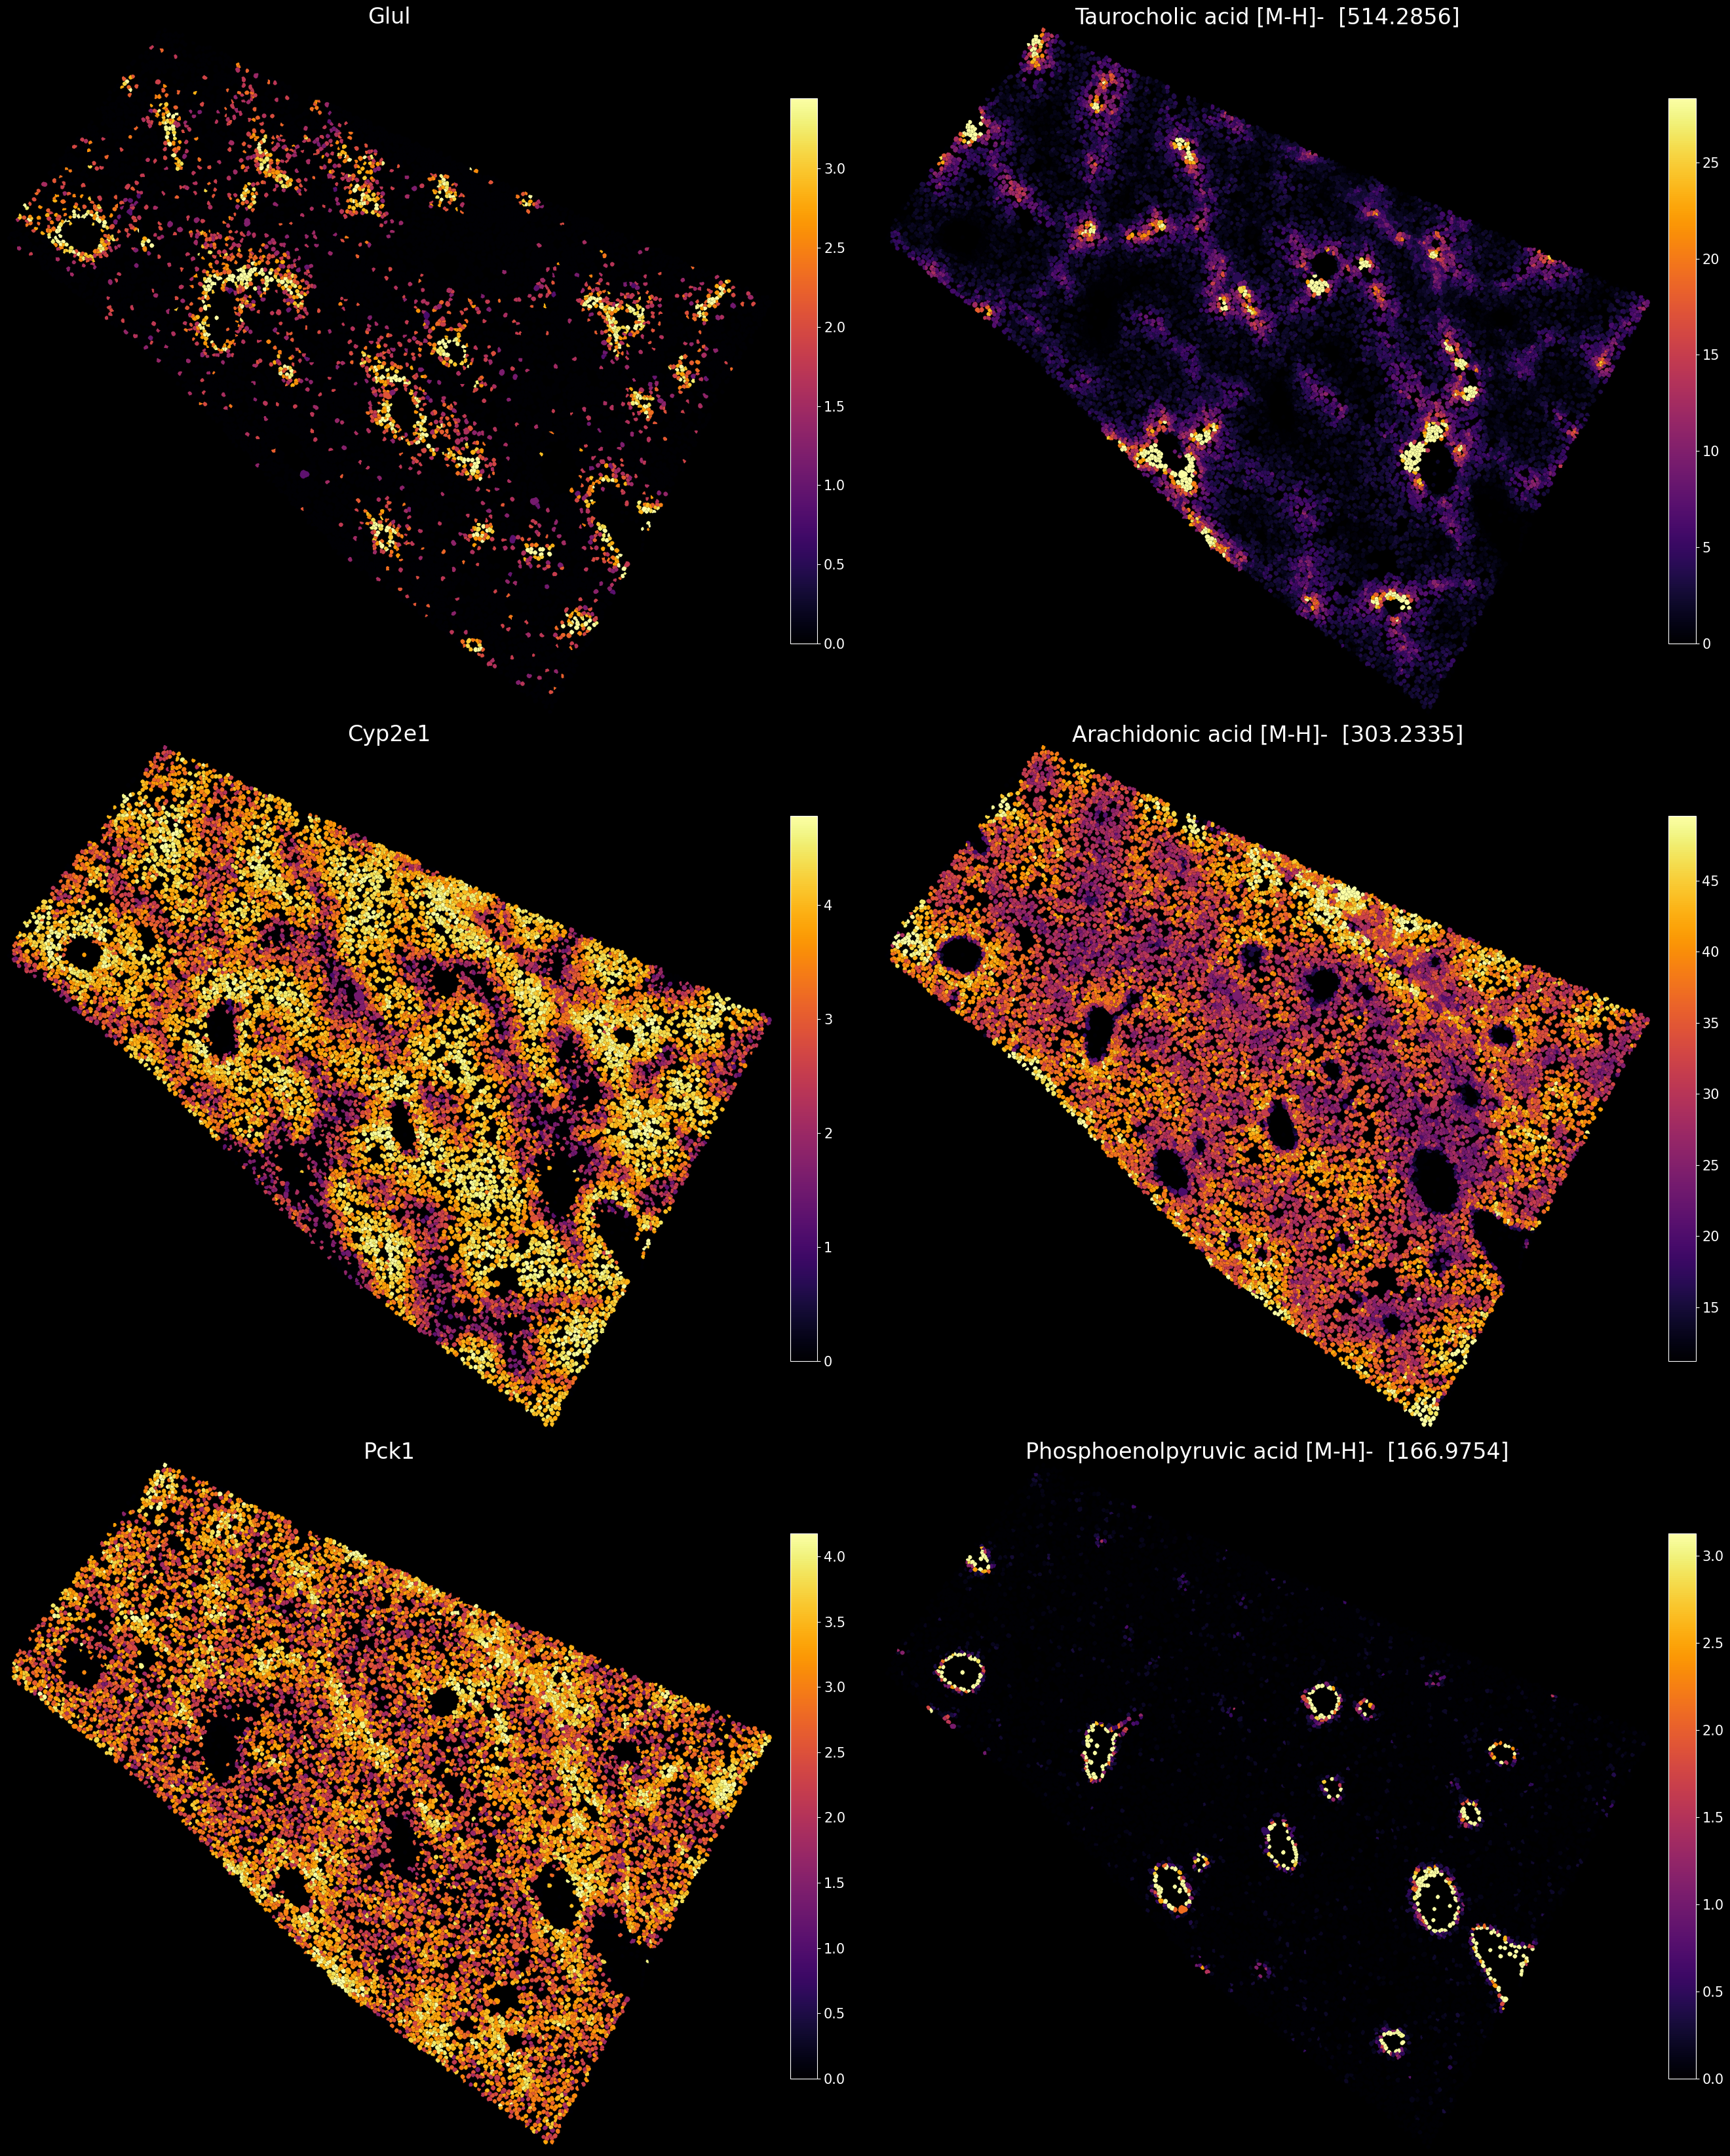

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
import seaborn as sns
import numpy as np

sns.set_style("dark")

def plot_features_grid(features: list[str], colormap: str = "inferno", ncols: int = 3, figsize_per_panel: tuple = (5, 4)):
    """
    Plot each feature as a panel in a grid, with cell polygons colored
    by median feature intensity.

    Parameters
    ----------
    features : list[str]
        Column names from final_maldi_visium_cell_df
    colormap : str
        Any matplotlib colormap name
    ncols : int
        Number of columns in the grid
    figsize_per_panel : tuple
        (width, height) per panel in inches
    """
    missing = [f for f in features if f not in maldi_subset_df.columns]
    if missing:
        raise ValueError(f"Features not found: {missing}")

    _, pixel_cell_idx = cell_centroid_tree.query(pixels_subset[["he_x", "he_y"]].values)
    cmap = plt.get_cmap(colormap)

    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        facecolor="black"
    )
    axes = np.array(axes).flatten()

    for ax, feature in zip(axes, features):
        # compute median per cell
        values = maldi_subset_df[feature].values[pixel_cell_idx]
        median_per_cell = np.array([
            np.median(values[pixel_cell_idx == i]) if np.any(pixel_cell_idx == i) else 0.0
            for i in range(len(maldi_subset_df))
        ])

        vmin, vmax = np.nanpercentile(median_per_cell, [2, 98])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

        # build polygon patches colored by feature value
        patches = []
        face_colors = []
        for poly_yx, val in zip(cell_polygons, median_per_cell):
            xy = poly_yx[:, [1, 0]]  # (row, col) → (x, y)
            patches.append(mpatches.Polygon(xy, closed=True))
            face_colors.append(cmap(norm(val)))

        pc = PatchCollection(patches, facecolors=face_colors, edgecolors="none", linewidths=0)
        ax.add_collection(pc)

        # set axis limits from polygon bounds
        all_xy = np.vstack([p[:, [1, 0]] for p in cell_polygons])
        ax.set_xlim(all_xy[:, 0].min(), all_xy[:, 0].max())
        ax.set_ylim(all_xy[:, 1].max(), all_xy[:, 1].min())  # invert y for image coords

        ax.set_aspect("equal")
        ax.set_facecolor("black")
        ax.set_title(feature, color="white", fontsize=24, pad=4)
        ax.axis("off")

        # colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
        cbar.ax.tick_params(colors="white", labelsize=15)

    # hide unused panels
    for ax in axes[len(features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig('Metabolomics_Transcriptomics.png')
    plt.show()


# example
features = [
    "Glul",
    "Taurocholic acid [M-H]-  [514.2856]",
    "Cyp2e1",
    "Arachidonic acid [M-H]-  [303.2335]",
    "Pck1",
    "Phosphoenolpyruvic acid [M-H]-  [166.9754]",
]
plot_features_grid(features, colormap="inferno", ncols=2, figsize_per_panel=(14, 11))
